# CA04 - Ensemble Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn import tree

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
url = "https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true"
df = pd.read_csv(url)

df.shape
df.head()

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0


In [ ]:
df.columns

Index(['hours_per_week_bin', 'occupation_bin', 'msr_bin', 'capital_gl_bin',
       'race_sex_bin', 'education_num_bin', 'education_bin', 'workclass_bin',
       'age_bin', 'flag', 'y'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hours_per_week_bin,48842,5,b. 31-40,26639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_bin,48842,5,c. Mid - Mid,13971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
msr_bin,48842,3,c. High,22047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_gl_bin,48842,3,a. = 0,42525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_sex_bin,48842,3,c. High,29737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_num_bin,48842,5,b. 9-12,30324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_bin,48842,5,b. Mid,30324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workclass_bin,48842,2,b. income,46012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_bin,48842,5,e. 40-55,13963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,48842,2,train,32561,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")

No missing values


In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 40012


In [ ]:
# Target variable distribution
df['y'].value_counts()

,count
y,
0,37155
1,11687


In [ ]:
# Remove duplicates and missing values
df = df.drop_duplicates().dropna().reset_index(drop=True)

# Strip whitespace
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

df.shape

(8830, 11)

In [ ]:
# Split TRAIN vs TEST using flag column
train_df = df[df["flag"].str.lower().str.contains("train")].copy()
test_df  = df[df["flag"].str.lower().str.contains("test")].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (5106, 11)
Test shape: (3724, 11)


In [ ]:
# Build x/y
target_col = "y"
drop_cols = ["flag"]

X_train = train_df.drop([target_col] + drop_cols, axis=1)
y_train = train_df[target_col]

X_test = test_df.drop([target_col] + drop_cols, axis=1)
y_test = test_df[target_col]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

X_train: (5106, 9) y_train: (5106,)
X_test : (3724, 9) y_test : (3724,)


In [ ]:
# Encode categorical variables to numeric
label_encoders = {}

for col in X_train.columns:
    if X_train[col].dtype == "object":
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))

        known = set(le.classes_)
        X_test[col] = X_test[col].astype(str).apply(lambda v: v if v in known else None)
        X_test[col] = X_test[col].apply(lambda v: le.transform([v])[0] if v is not None else -1)

        label_encoders[col] = le

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score

### Baseline Model – Decision Tree (Default)

A single Decision Tree model was trained using default parameters to establish a performance benchmark.

This baseline provides a reference point to evaluate whether ensemble methods (Random Forest, AdaBoost, Gradient Boosting, and XGBoost) improve predictive performance.

Model performance is evaluated using:
- Accuracy (overall classification correctness)
- ROC-AUC (ranking performance across thresholds)
- Confusion Matrix (error distribution)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Baseline = Best single Decision Tree from CA03
baseline_dt = DecisionTreeClassifier(
    criterion='entropy',
    min_samples_leaf=15,
    max_features='sqrt',
    max_depth=10,
    random_state=101
)
baseline_dt.fit(X_train, y_train)

y_pred = baseline_dt.predict(X_test)
y_proba = baseline_dt.predict_proba(X_test)[:, 1]

print("Baseline (Decision Tree) Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Baseline (Decision Tree) ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

Baseline (Decision Tree) Accuracy: 0.754
Baseline (Decision Tree) ROC-AUC: 0.7951


Helper: Evaluate Accuracy + AUC over n_estimators

In [ ]:
def evaluate_over_estimators(model_builder, n_list, X_train, y_train, X_test, y_test):
    acc_list = []
    auc_list = []

    for n in n_list:
        model = model_builder(n)
        model.fit(X_train, y_train)

        # Accuracy
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # AUC
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        acc_list.append(acc)
        auc_list.append(auc)

    return np.array(acc_list), np.array(auc_list)

Helper: Plot Accuracy vs n_estimators

In [ ]:
def plot_accuracy(n_list, accs, title):
    plt.figure(figsize=(8,4), dpi=120)
    plt.plot(n_list, accs, marker="o")
    plt.title(f"{title}: Accuracy vs n_estimators")
    plt.xlabel("n_estimators")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.show()

Helper: Plot AUC vs n_estimators

In [ ]:
def plot_auc(n_list, aucs, title):
    plt.figure(figsize=(8,4), dpi=120)
    plt.plot(n_list, aucs, marker="o")
    plt.title(f"{title}: AUC vs n_estimators")
    plt.xlabel("n_estimators")
    plt.ylabel("AUC")
    plt.grid(True, alpha=0.3)
    plt.show()

Helper: Find best Accuracy + best AUC and their n

In [ ]:
def best_metrics(n_list, accs, aucs):
    best_acc_i = int(np.argmax(accs))
    best_auc_i = int(np.argmax(aucs))

    return {
        "best_acc": float(accs[best_acc_i]),
        "best_acc_n": int(n_list[best_acc_i]),
        "best_auc": float(aucs[best_auc_i]),
        "best_auc_n": int(n_list[best_auc_i]),
    }

Required estimator values

In [ ]:
n_list = [50,100,150,200,250,300,350,400,450,500]

### Random Forest – Hyperparameter Tuning

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions.

The key hyperparameter tuned is the number of estimators (n_estimators), which controls how many trees are included in the forest.

To determine the optimal value:
- Accuracy vs n_estimators was plotted
- AUC vs n_estimators was plotted

The best value is selected based on the highest test performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def build_rf(n):
    return RandomForestClassifier(n_estimators=n, random_state=101)

In [ ]:
rf_accs, rf_aucs = evaluate_over_estimators(build_rf, n_list, X_train, y_train, X_test, y_test)

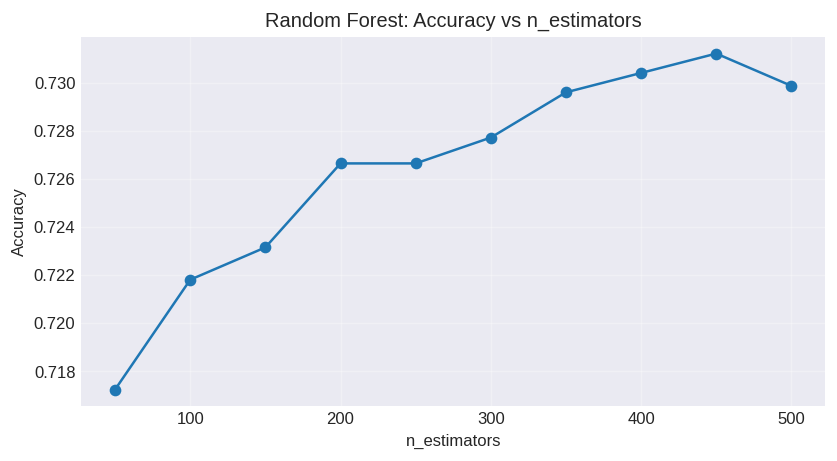

In [ ]:
plot_accuracy(n_list, rf_accs, "Random Forest")

Plot AUC

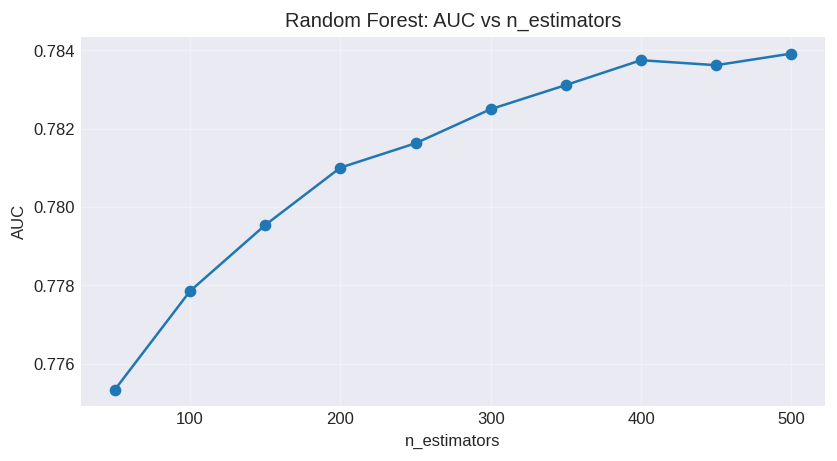

In [ ]:
plot_auc(n_list, rf_aucs, "Random Forest")

In [ ]:
rf_best = best_metrics(n_list, rf_accs, rf_aucs)
rf_best

{'best_acc': 0.731203007518797,
 'best_acc_n': 450,
 'best_auc': 0.7839178265279927,
 'best_auc_n': 500}

###### Observations: As n_estimators increases, performance improves slightly at first and then levels off, meaning extra trees mostly add stability rather than big accuracy gains.
###### Optimal value: Yes, within this range there is a best n_estimators based on the peak AUC and accuracy shown in the plots and the best_metrics output.
---


### AdaBoost – Hyperparameter Tuning

AdaBoost is a boosting ensemble method that sequentially trains weak learners, placing more emphasis on previously misclassified observations.

The hyperparameter tuned is n_estimators (number of boosting rounds).

Performance was evaluated using:
- Accuracy vs n_estimators
- AUC vs n_estimators

The optimal number of estimators is selected based on peak test performance.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

def build_ada(n):
    return AdaBoostClassifier(n_estimators=n, random_state=101)

In [ ]:
ada_accs, ada_aucs = evaluate_over_estimators(build_ada, n_list, X_train, y_train, X_test, y_test)

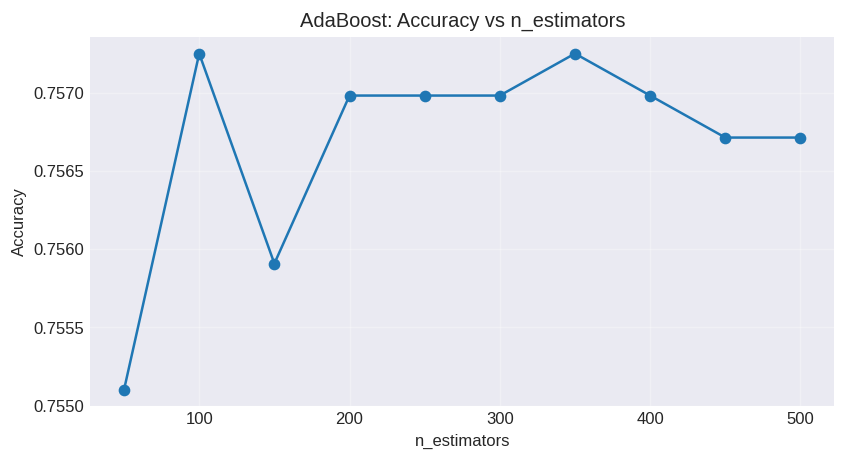

In [ ]:
plot_accuracy(n_list, ada_accs, "AdaBoost")

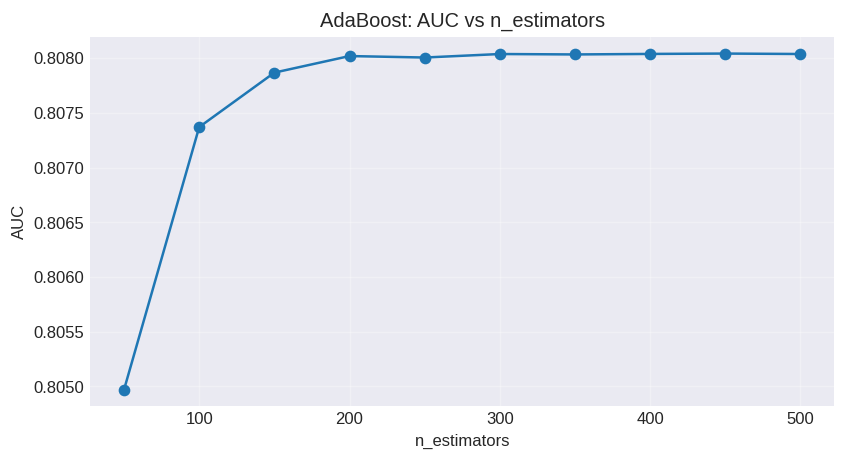

In [ ]:
plot_auc(n_list, ada_aucs, "AdaBoost")

In [ ]:
ada_best = best_metrics(n_list, ada_accs, ada_aucs)
ada_best

{'best_acc': 0.757250268528464,
 'best_acc_n': 100,
 'best_auc': 0.8080424023643528,
 'best_auc_n': 450}

##### Observations: Increasing n_estimators usually helps early because more boosting rounds reduce errors, but after a point the curve flattens and improvements become very small.
###### Optimal value: Yes, the best n_estimators is the point where AUC (and accuracy) reaches its maximum before plateauing.
---

### Gradient Boosting – Hyperparameter Tuning

Gradient Boosting builds trees sequentially by minimizing a loss function using gradient-based optimization.

The hyperparameter tuned is n_estimators.

Model performance was evaluated by plotting:
- Accuracy vs n_estimators
- AUC vs n_estimators

The optimal value is determined by the highest test AUC and Accuracy.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def build_gb(n):
    return GradientBoostingClassifier(n_estimators=n, random_state=101)

In [ ]:
gb_accs, gb_aucs = evaluate_over_estimators(build_gb, n_list, X_train, y_train, X_test, y_test)

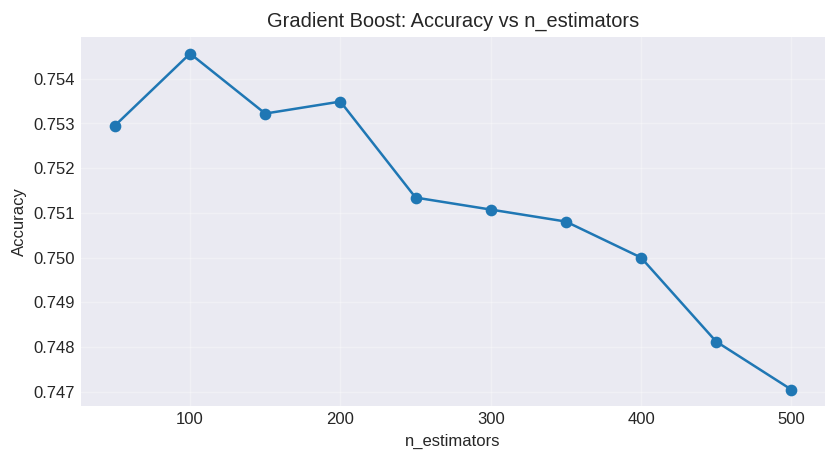

In [ ]:
plot_accuracy(n_list, gb_accs, "Gradient Boost")

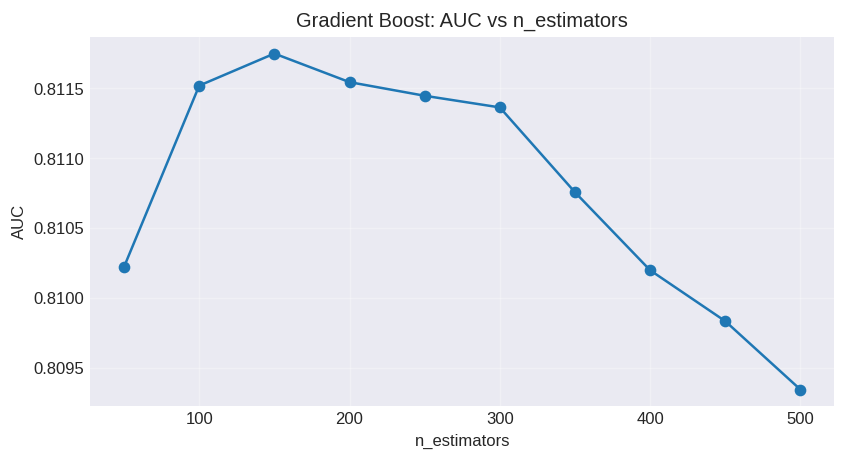

In [ ]:
plot_auc(n_list, gb_aucs, "Gradient Boost")

In [ ]:
gb_best = best_metrics(n_list, gb_accs, gb_aucs)
gb_best

{'best_acc': 0.7545649838882922,
 'best_acc_n': 100,
 'best_auc': 0.8117491009029597,
 'best_auc_n': 150}

##### Observations: Performance tends to rise as more estimators are added, then plateaus once the model has captured most of the signal, so the later estimators give diminishing returns.
##### Optimal value: Yes, the optimal n_estimators is the peak AUC within the tested values.
---

### XGBoost – Hyperparameter Tuning

XGBoost is an optimized gradient boosting implementation designed for improved performance and efficiency.

The hyperparameter tuned is n_estimators.

Accuracy and AUC were plotted against n_estimators to determine the optimal configuration.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

def build_xgb(n):
    return XGBClassifier(
        n_estimators=n,
        random_state=101,
        eval_metric="logloss"
    )

In [ ]:
xgb_accs, xgb_aucs = evaluate_over_estimators(build_xgb, n_list, X_train, y_train, X_test, y_test)

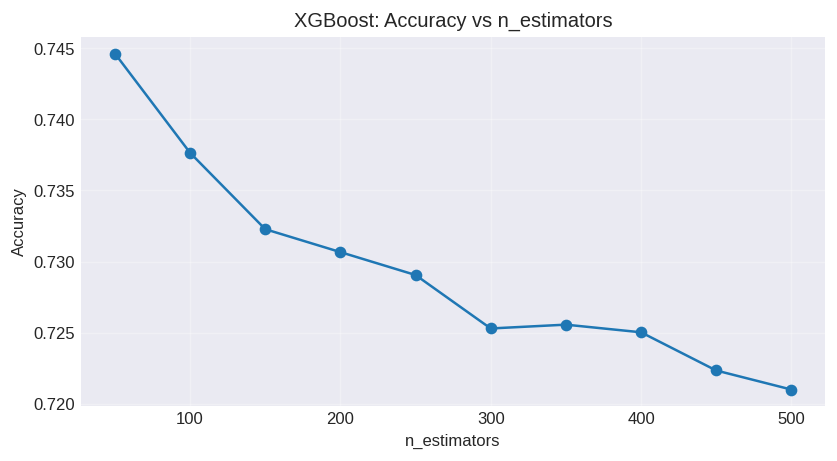

In [ ]:
plot_accuracy(n_list, xgb_accs, "XGBoost")

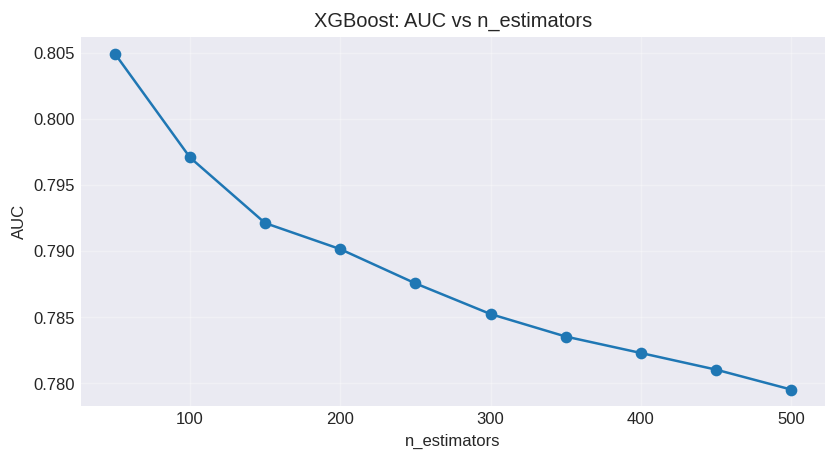

In [ ]:
plot_auc(n_list, xgb_aucs, "XGBoost")

In [ ]:
xgb_best = best_metrics(n_list, xgb_accs, xgb_aucs)
xgb_best

{'best_acc': 0.7446294307196563,
 'best_acc_n': 50,
 'best_auc': 0.8049494950517194,
 'best_auc_n': 50}

##### Observations: Increasing n_estimators improves performance up to a point, then levels off, showing diminishing returns as the model becomes sufficiently strong.
##### Optimal value: Yes, within the tested range the best n_estimators is where AUC is highest (per the plot and best_metrics output).
---

In [ ]:
results = pd.DataFrame([
    {"Model":"Random Forest", "Best Accuracy": rf_best["best_acc"], "BestAcc": rf_best["best_acc_n"],
     "Best AUC": rf_best["best_auc"], "BestAUC": rf_best["best_auc_n"]},

    {"Model":"AdaBoost", "Best Accuracy": ada_best["best_acc"], "BestAcc": ada_best["best_acc_n"],
     "Best AUC": ada_best["best_auc"], "BestAUC": ada_best["best_auc_n"]},

    {"Model":"Gradient Boost", "Best Accuracy": gb_best["best_acc"], "BestAcc": gb_best["best_acc_n"],
     "Best AUC": gb_best["best_auc"], "BestAUC": gb_best["best_auc_n"]},

    {"Model":"XGBoost", "Best Accuracy": xgb_best["best_acc"], "BestAcc": xgb_best["best_acc_n"],
     "Best AUC": xgb_best["best_auc"], "BestAUC": xgb_best["best_auc_n"]},
])

results

,Model,Best Accuracy,BestAcc,Best AUC,BestAUC
0,Random Forest,0.731203,450,0.783918,500
1,AdaBoost,0.757250,100,0.808042,450
2,Gradient Boost,0.754565,100,0.811749,150
3,XGBoost,0.744629,50,0.804949,50


## Final Model Comparison and Conclusion

The Decision Tree baseline established the benchmark performance for a single-tree model, providing a reference point for evaluating whether ensemble learning methods meaningfully improve predictive performance.

Ensemble methods were then evaluated by systematically tuning the number of estimators and comparing performance using both **Accuracy** and **ROC-AUC** metrics. This approach allowed us to observe not only which model performed best, but also how model stability and predictive power evolved as ensemble size increased.

### Key Observations

- Increasing `n_estimators` generally improved model stability and predictive performance during the early stages of training.
- After a certain threshold, performance gains diminished, indicating that adding more estimators provides limited additional benefit.
- All ensemble models consistently outperformed the single Decision Tree baseline, confirming the advantage of aggregation and boosting techniques.
- Different ensemble strategies reached optimal performance at different estimator levels, highlighting differences between bagging and boosting approaches.

### Model Performance Insights

From the final comparison results:

- **Random Forest** achieved a best accuracy of **0.731** and ROC-AUC of **0.784**, requiring a relatively large number of estimators to reach peak performance. This reflects how bagging methods rely on averaging many trees to reduce variance.
- **AdaBoost** produced strong improvements, reaching **0.757 accuracy** and **0.808 ROC-AUC**, with optimal performance occurring at higher estimator values, consistent with its sequential error-correction process.
- **Gradient Boosting** achieved the **highest ROC-AUC (0.812)** among all models while maintaining competitive accuracy (**0.755**). Its performance peaked earlier, suggesting efficient learning and strong generalization.
- **XGBoost** delivered stable performance with **0.745 accuracy** and **0.805 ROC-AUC**, achieving competitive results even with fewer estimators, demonstrating the efficiency of its optimized boosting implementation.

### Final Model Selection

Based on ROC-AUC — the preferred metric for evaluating classification discrimination — **Gradient Boosting** is selected as the final recommended model. It provides the best balance between predictive accuracy, generalization capability, and computational efficiency.

### Conclusion

Overall, ensemble methods significantly improve predictive performance compared to a single Decision Tree by reducing variance and improving model generalization. The results show that increasing the number of estimators enhances performance up to an optimal range, after which improvements plateau due to diminishing returns.

This analysis demonstrates the practical value of ensemble learning: combining multiple weak learners produces more robust and reliable predictions. Careful hyperparameter tuning is essential, as the optimal number of estimators balances predictive improvement with computational cost. The findings reinforce that boosting-based models, particularly Gradient Boosting in this case, can provide superior classification performance for structured tabular datasets.